# Transformer & Attention Interview Preparation Notes

*A First-Principles Guide*

---

## Table of Contents

1. Why were RNNs invented?
2. What is a Hidden State?
3. Why is the Hidden State a Bottleneck?
4. Why were LSTMs invented?
5. Why was the Encoder-Decoder architecture introduced?
6. Why was Attention invented?
7. How does Attention work in RNNs?
8. Limitations of RNN Attention
9. Why was the Transformer invented?
10. What is Self-Attention?
11. Query, Key and Value
12. Why do we need Q, K and V?
13. Difference between RNN Attention and Transformer Self-Attention
14. Common Interview Questions

---

# 1. Why were RNNs invented?

## Interview Question

**Why do we need RNNs? Why can't we use a normal feedforward neural network for language modeling?**

---

## Answer

A feedforward neural network treats every input independently.

For example,

```
I love deep learning
```

If we want to predict the next word,

a feedforward network only looks at a fixed-size window.

Example:

```
Input

love deep learning

↓

Predict

models
```

It has **no memory** of earlier words.

Natural language is sequential.

The meaning of a word depends on previous words.

Researchers therefore introduced the **Recurrent Neural Network (RNN)**.

Instead of processing every word independently,

the RNN carries information from previous words.

```
Word1

↓

Hidden State 1

↓

Word2

↓

Hidden State 2

↓

Word3

↓

Hidden State 3
```

Each hidden state summarizes everything the model has seen so far.

---

# 2. What is a Hidden State?

## Interview Question

**What is the hidden state in an RNN?**

---

## Answer

A hidden state is simply the model's **memory**.

After reading every word,

the memory gets updated.

Suppose we read

```
I

↓

love

↓

AI
```

Initially

```
Memory

[0,0,0]
```

After reading

```
I
```

```
Memory

[0.4,0.2,-0.1]
```

After reading

```
love
```

```
Memory

[0.8,-0.5,0.7]
```

The hidden state is **not storing words**.

Instead,

it stores a **numerical representation** of everything read so far.

---

# 3. Why is the Hidden State a Bottleneck?

## Interview Question

**Why isn't the hidden state enough?**

---

## Answer

Suppose the hidden state size is

```
512
```

This does **NOT** mean

```
512 words
```

It means

```
512 floating-point numbers
```

These numbers must summarize

- grammar
- context
- entities
- relationships
- meaning
- topic

for the entire sentence.

For a short sentence,

this works well.

For a long sentence,

```
1000 words

↓

512 numbers
```

Everything must still fit into those same 512 values.

This creates an information bottleneck.

---

## Analogy

Imagine summarizing an entire novel using one sticky note.

Eventually,

important details disappear.

---

# 4. Why were LSTMs invented?

## Interview Question

**Why were LSTMs introduced if RNNs already had memory?**

---

## Answer

The RNN updates its hidden state every step.

```
Old Memory

+

Current Word

↓

New Memory
```

After many updates,

old information gradually disappears.

This problem is related to the **vanishing gradient problem**.

LSTMs introduce a **cell state** and three gates.

- Forget Gate
- Input Gate
- Output Gate

These gates decide

- what to remember
- what to forget
- what to expose

LSTMs preserve important information much longer than vanilla RNNs.

---

# 5. Why was the Encoder-Decoder architecture introduced?

## Interview Question

**Why do we need Encoder-Decoder models?**

---

## Answer

Tasks like translation require

```
English

↓

French
```

The encoder reads the English sentence.

```
I

↓

love

↓

machine

↓

learning
```

The decoder generates French.

Initially,

the decoder only received

```
Final Hidden State
```

This single vector had to summarize the entire source sentence.

This became another bottleneck.

---

# 6. Why was Attention invented?

## Interview Question

**Why was Attention invented?**

---

## Answer

Researchers realized

instead of forcing the decoder to use only

```
Final Hidden State
```

why not allow it to look at

```
h1

h2

h3

...

hn
```

This allows the decoder to retrieve information from whichever encoder hidden states are most relevant.

---

## Example

English

```
I love machine learning
```

When generating

```
learning
```

the decoder assigns

| Hidden State | Weight |
|--------------|---------|
| h1 | 0.05 |
| h2 | 0.10 |
| h3 | 0.25 |
| h4 | 0.60 |

Instead of relying only on h4,

it computes

```
Context

=

0.05*h1

+

0.10*h2

+

0.25*h3

+

0.60*h4
```

This context vector changes for every output word.

---

# 7. How does Attention work?

## Interview Question

**Explain Attention step by step.**

---

## Answer

The decoder

1. looks at all encoder hidden states
2. computes an importance score
3. converts scores into probabilities
4. computes a weighted average
5. produces a context vector

Every output word gets its own context vector.

---

# 8. What problems still remain?

## Interview Question

**Did Attention completely solve RNN problems?**

---

## Answer

No.

Although Attention improves translation,

the encoder is still an RNN.

Hidden states are still created sequentially.

```
h1

↓

h2

↓

h3

↓

...

↓

hn
```

Problems remain

- sequential computation
- difficult GPU parallelization
- long dependency chain

---

# 9. Why was the Transformer invented?

## Interview Question

**Why was the Transformer invented?**

---

## Answer

Researchers asked

> If Attention is doing most of the work,
> why do we still need the RNN?

Instead of

```
RNN

↓

Attention
```

they proposed

```
Attention

↓

Feed Forward

↓

Attention

↓

Feed Forward
```

No recurrence.

No sequential hidden-state updates.

---

## Benefits

- Parallel computation
- Better GPU utilization
- Easier optimization
- Better long-range dependency modeling

---

# 10. What is Self-Attention?

## Interview Question

**What is Self-Attention?**

---

## Answer

Self-attention allows every word to interact with every other word.

Sentence

```
The cat drank milk
```

Word

```
drank
```

can directly obtain information from

- cat
- milk

without waiting for information to flow through multiple recurrent steps.

Every token updates its representation using information from the entire sentence.

---

# 11. What are Query, Key and Value?

## Interview Question

**Explain Query, Key and Value intuitively.**

---

## Answer

Imagine a library.

You ask

```
I need books on Deep Learning.
```

Your request

↓

**Query**

Every book has a label

↓

**Key**

If a label matches,

you receive the book

↓

**Value**

---

Transformer

Each word creates

- Query
- Key
- Value

The Query compares itself with every Key.

The highest matching Keys determine which Values should contribute.

---

# 12. Why do we need Query, Key and Value?

## Interview Question

**Why not use one vector instead of Q, K and V?**

---

## Answer

One vector would have to perform three different jobs.

- Ask questions
- Advertise available information
- Store information

Separating these responsibilities gives the model more flexibility.

Think of

Query

↓

"What am I looking for?"

Key

↓

"What kind of information do I contain?"

Value

↓

"This is the information I'll provide."

---

# 13. Difference between RNN Attention and Transformer Attention

| RNN Attention | Transformer Self-Attention |
|--------------|----------------------------|
| Decoder attends to Encoder | Every token attends to every token |
| Encoder is sequential | No recurrence |
| Attention added on top | Attention is the architecture |
| Slower training | Parallel training |
| Long dependency chain | Direct interaction |

---

# 14. Most Common Interview Questions

---

## Q1

**Does a hidden state store words?**

### Answer

No.

It stores learned numerical features.

Words are transformed into dense vector representations.

---

## Q2

**Does a hidden state grow with sentence length?**

### Answer

No.

A hidden state always has a fixed dimension.

Example

```
512 numbers
```

Whether the sentence has

- 5 words
- 100 words
- 1000 words

the hidden state remains

```
512 numbers
```

---

## Q3

**Why is that a problem?**

### Answer

Longer sentences require more information.

Compressing all information into a fixed-size vector causes information loss.

---

## Q4

**What does Attention solve?**

### Answer

Instead of relying on one compressed summary,

the model keeps every hidden state

```
h1

h2

...

hn
```

and dynamically retrieves the most relevant ones.

---

## Q5

**Does Attention eliminate recurrence?**

### Answer

No.

Attention in Seq2Seq models is still built on top of an RNN.

Only Transformers eliminate recurrence.

---

## Q6

**What is the biggest innovation of the Transformer?**

### Answer

Removing recurrence completely.

Every token communicates directly with every other token using self-attention.

---

## Q7

**Why is Self-Attention faster?**

### Answer

RNN

```
Word1

↓

Word2

↓

Word3

↓

Word4
```

Transformer

```
Word1

Word2

Word3

Word4

↓

Processed Together
```

GPUs are optimized for parallel matrix operations.

---

## Q8

**What is the intuition behind Query, Key and Value?**

### Answer

Query

> What am I looking for?

Key

> What information do I have?

Value

> What information will I provide if selected?

---

## Q9

**Why are Residual Connections important?**

### Answer

Residual connections allow information to bypass layers.

Instead of

```
Output = F(x)
```

they compute

```
Output = x + F(x)
```

Benefits

- Prevent vanishing gradients
- Preserve information
- Enable very deep networks
- Improve convergence

---

## Q10

**What is the biggest difference between Attention and Self-Attention?**

### Answer

Attention

Decoder attends to encoder.

Self-Attention

Every token attends to every other token within the same sequence.

---

# Final Interview Summary

If asked:

**"Why did Transformers replace RNNs?"**

A strong answer is:

> RNNs process sequences sequentially, making training slow and causing information to degrade over long sequences. Although attention improved encoder-decoder models by allowing the decoder to access all encoder hidden states, those hidden states were still generated one at a time by the RNN. Transformers removed recurrence entirely and replaced it with self-attention, allowing every token to directly interact with every other token in parallel. This significantly improved long-range dependency modeling, training efficiency, and scalability, making modern large language models possible.

# Context learning


# Positional Encoding
Positional embeddings (or positional encodings) address a key limitation in the Transformer architecture: the self-attention mechanism is permutation-invariant (order doesn't matter). Without explicit position information, the model wouldn't know the sequence order of tokens (words, patches, etc.).


Let:

$  pos  $ = position in the sequence ($0, 1, 2, \dots, n-1$)
$  d_{model}  $ = model dimension (embedding size, e.g., 512 or 768)
$  i  $ = dimension index ($0 \leq i < d_{model}/2$)

The positional encoding vector $  \mathbf{PE}(pos)  $ is defined as:
$$PE(pos, 2i) = \sin\left( \frac{pos}{10000^{2i / d_{model}}} \right)$$
$$PE(pos, 2i+1) = \cos\left( \frac{pos}{10000^{2i / d_{model}}} \right)$$
For each even dimension $2i$ we use sine, and for the next odd dimension $2i+1$ we use cosine, with the same frequency.

### Why These Frequencies?
The term $10000^{2i / d_{model}}$ controls the wavelength (period) for each dimension:

- For small $  i  $ (low dimensions): $10000^{2i/d} \approx 1$, so high frequency (fast oscillation).
- For large $  i  $ (high dimensions): $10000^{2i/d}$ becomes very large, so low frequency (slow oscillation).

This creates a geometric progression of wavelengths from $2\pi$ up to $10000 \times 2\pi$ (roughly). Different dimensions "tick" at different rates, giving the model rich positional signals across scales.


### Key Mathematical Properties
- **a) Relative position encoding via linear relationships**:
This is the most elegant property. Consider the dot product or linear combinations between two positions:
Using trigonometric identities, you can show that:
$$PE(pos + k, \cdot) = f(PE(pos, \cdot), k)$$
for some linear function $  f  $ (involving rotation matrices). Specifically, for any fixed offset $  k  $:
$$\begin{bmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
\begin{bmatrix}
PE(pos, 2i) \\
PE(pos, 2i+1)
\end{bmatrix}
\approx
\begin{bmatrix}
PE(pos+k, 2i) \\
PE(pos+k, 2i+1)
\end{bmatrix}$$
where $  \theta = k / 10000^{2i/d_{model}}  $.
This means the model can easily learn to attend based on relative distances rather than absolute positions. Attention layers can extract "how far apart" two tokens are using simple operations on the encodings.

- **b) Periodicity and uniqueness:**
Sine and cosine are periodic but, because frequencies are different across dimensions, the combination of values across the full $  d_{model}  $ vector is unique for each position (within a long enough range).
- **c) Bounded values:**
All values stay in $  [-1, 1]  $, which matches the scale of normalized embeddings and helps with training stability.
- **d) Extrapolation to longer sequences:**
Because it's a fixed mathematical function (not learned), it generalizes to sequence lengths longer than those seen during training. Learned positional embeddings often struggle with this.


### Main Reasons for Using Sin and Cos
They enable easy encoding of relative positions (the most important reason)
This is the killer property. Using the trigonometric addition formulas, we get a linear relationship between positions:
$$\sin(a + b) = \sin a \cdot \cos b + \cos a \cdot \sin b$$
$$\cos(a + b) = \cos a \cdot \cos b - \sin a \cdot \sin b$$
If you treat each pair of dimensions $  (2i, 2i+1)  $ as a 2D vector, shifting the position by a fixed offset $  k  $ is equivalent to multiplying by a rotation matrix:
$$\begin{bmatrix}
PE(pos+k, 2i) \\
PE(pos+k, 2i+1)
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
PE(pos, 2i) \\
PE(pos, 2i+1)
\end{bmatrix}$$
where $  \theta = k / 10000^{2i/d_{model}}  $.
This rotation property makes it very easy for the attention mechanism to learn relative distances between tokens. The model doesn't need to learn complex functions — simple linear transformations (which attention is good at) suffice.


## Positional Encoding: Step-by-Step Mathematical Breakdown

## Parameters
- `d_model = 4` (Total dimensions of our embedding vector)
- **Pair 1**: `i = 0` → even column `2i = 0`, odd column `2i + 1 = 1`
- **Pair 2**: `i = 1` → even column `2i = 2`, odd column `2i + 3 = 3`

---

## 1. Positional Encoding Matrix ($PE$)

For `i = 0`, the angle divisor constant is $10000^{\frac{0}{4}} = 1$.  
The frequency angle simplifies to: $\theta_0 = \text{pos}$

For `i = 1`, the angle divisor constant is $10000^{\frac{2}{4}} = 100$.  
The frequency angle simplifies to: $\theta_1 = \frac{\text{pos}}{100}$

### Exact Step-by-Step Matrix Generation

| Word | Position (pos) | Pair 1: Even (2i=0) <br> `sin(pos)` | Pair 1: Odd (2i+1=1) <br> `cos(pos)` | Pair 2: Even (2i=2) <br> `sin(pos/100)` | Pair 2: Odd (2i+3=3) <br> `cos(pos/100)` |
|------|---------------|--------------------------------------|---------------------------------------|-------------------------------------------|--------------------------------------------|
| "I" | 0 | $\sin(0) = \mathbf{0.0}$ | $\cos(0) = \mathbf{1.0}$ | $\sin(0) = \mathbf{0.0}$ | $\cos(0) = \mathbf{1.0}$ |
| "like" | 1 | $\sin(1) = \mathbf{0.8415}$ | $\cos(1) = \mathbf{0.5403}$ | $\sin(0.01) = \mathbf{0.0100}$ | $\cos(0.01) = \mathbf{0.9999}$ |
| "playing" | 2 | $\sin(2) = \mathbf{0.9093}$ | $\cos(2) = \mathbf{-0.4161}$ | $\sin(0.02) = \mathbf{0.0200}$ | $\cos(0.02) = \mathbf{0.9998}$ |
| "football" | 3 | $\sin(3) = \mathbf{0.1411}$ | $\cos(3) = \mathbf{-0.9900}$ | $\sin(0.03) = \mathbf{0.0300}$ | $\cos(0.03) = \mathbf{0.9996}$ |
| "in" | 4 | $\sin(4) = \mathbf{-0.7568}$ | $\cos(4) = \mathbf{-0.6536}$ | $\sin(0.04) = \mathbf{0.0400}$ | $\cos(0.04) = \mathbf{0.9992}$ |
| "my" | 5 | $\sin(5) = \mathbf{-0.9589}$ | $\cos(5) = \mathbf{0.2837}$ | $\sin(0.05) = \mathbf{0.0500}$ | $\cos(0.05) = \mathbf{0.9988}$ |
| "leisure" | 6 | $\sin(6) = \mathbf{-0.2794}$ | $\cos(6) = \mathbf{0.9602}$ | $\sin(0.06) = \mathbf{0.0599}$ | $\cos(0.06) = \mathbf{0.9982}$ |
| "time" | 7 | $\sin(7) = \mathbf{0.6570}$ | $\cos(7) = \mathbf{0.7539}$ | $\sin(0.07) = \mathbf{0.0699}$ | $\cos(0.07) = \mathbf{0.9976}$ |

---

## 2. Calculating Rotation and Relative Distance

Let's compute the linear rotation shift between two specific rows using our algebraic transformation framework:

| | |
|---|---|
| **Base word vector** | $PE_{\text{pos}}$: "like" at `pos = 1` |
| **Target word vector** | $PE_{\text{pos}+k}$: "football" at `pos = 3` |
| **Relative Distance** | $k = 3 - 1 = 2$ |

We track calculations explicitly for **Pair 1 (`i = 0`)**, where our relative shift angle is:

$$\theta_0(k) = k = 2 \text{ radians}$$

---

### Step-by-Step Transformation Equation

$$
\begin{bmatrix} PE_{(3, 0)} \\ PE_{(3, 1)} \end{bmatrix}
=
\begin{bmatrix} \cos(2) & \sin(2) \\ -\sin(2) & \cos(2) \end{bmatrix}
\begin{bmatrix} PE_{(1, 0)} \\ PE_{(1, 1)} \end{bmatrix}
$$

Substituting trigonometric values ($\cos(2) \approx -0.4161$, $\sin(2) \approx 0.9093$):

$$
\begin{bmatrix} PE_{(3, 0)} \\ PE_{(3, 1)} \end{bmatrix}
=
\begin{bmatrix} -0.4161 & 0.9093 \\ -0.9093 & -0.4161 \end{bmatrix}
\begin{bmatrix} 0.8415 \\ 0.5403 \end{bmatrix}
$$

---

### Row 1: Even Coordinate (for "football")

$$\text{Row 1 Value} = (\text{rotation\_matrix}[0][0] \times \text{like\_vector}[0]) + (\text{rotation\_matrix}[0][1] \times \text{like\_vector}[1])$$

$$\text{Row 1 Value} = (-0.4161 \times 0.8415) + (0.9093 \times 0.5403)$$

$$\text{Row 1 Value} = -0.3501 + 0.4913 = \mathbf{0.1412}$$

✅ Matches $PE_{(3, 0)}$ from our matrix (within rounding limits).

---

### Row 2: Odd Coordinate (for "football")

$$\text{Row 2 Value} = (\text{rotation\_matrix}[1][0] \times \text{like\_vector}[0]) + (\text{rotation\_matrix}[1][1] \times \text{like\_vector}[1])$$

$$\text{Row 2 Value} = (-0.9093 \times 0.8415) + (-0.4161 \times 0.5403)$$

$$\text{Row 2 Value} = -0.7652 - 0.2248 = \mathbf{-0.9900}$$

✅ Matches $PE_{(3, 1)}$ from our matrix perfectly.

## Positional Encoding: Step-by-Step Mathematical Breakdown

## Parameters
- `d_model = 4` (Total dimensions of our embedding vector)
- **Pair 1**: `i = 0` → even column `2i = 0`, odd column `2i + 1 = 1`
- **Pair 2**: `i = 1` → even column `2i = 2`, odd column `2i + 3 = 3`

---

## 1. Positional Encoding Matrix ($PE$)

For `i = 0`, the angle divisor constant is $10000^{\frac{0}{4}} = 1$.  
The frequency angle simplifies to: $\theta_0 = \text{pos}$

For `i = 1`, the angle divisor constant is $10000^{\frac{2}{4}} = 100$.  
The frequency angle simplifies to: $\theta_1 = \frac{\text{pos}}{100}$

### Exact Step-by-Step Matrix Generation

| Word | Position (pos) | Pair 1: Even (2i=0) | Pair 1: Odd (2i+1=1) | Pair 2: Even (2i=2) | Pair 2: Odd (2i+3=3) |
|------|---------------|---------------------|----------------------|---------------------|----------------------|
| | | `sin(pos)` | `cos(pos)` | `sin(pos/100)` | `cos(pos/100)` |
| "I" | 0 | $\sin(0) = \mathbf{0.0}$ | $\cos(0) = \mathbf{1.0}$ | $\sin(0) = \mathbf{0.0}$ | $\cos(0) = \mathbf{1.0}$ |
| "like" | 1 | $\sin(1) = \mathbf{0.8415}$ | $\cos(1) = \mathbf{0.5403}$ | $\sin(0.01) = \mathbf{0.0100}$ | $\cos(0.01) = \mathbf{0.9999}$ |
| "playing" | 2 | $\sin(2) = \mathbf{0.9093}$ | $\cos(2) = \mathbf{-0.4161}$ | $\sin(0.02) = \mathbf{0.0200}$ | $\cos(0.02) = \mathbf{0.9998}$ |
| "football" | 3 | $\sin(3) = \mathbf{0.1411}$ | $\cos(3) = \mathbf{-0.9900}$ | $\sin(0.03) = \mathbf{0.0300}$ | $\cos(0.03) = \mathbf{0.9996}$ |
| "in" | 4 | $\sin(4) = \mathbf{-0.7568}$ | $\cos(4) = \mathbf{-0.6536}$ | $\sin(0.04) = \mathbf{0.0400}$ | $\cos(0.04) = \mathbf{0.9992}$ |
| "my" | 5 | $\sin(5) = \mathbf{-0.9589}$ | $\cos(5) = \mathbf{0.2837}$ | $\sin(0.05) = \mathbf{0.0500}$ | $\cos(0.05) = \mathbf{0.9988}$ |
| "leisure" | 6 | $\sin(6) = \mathbf{-0.2794}$ | $\cos(6) = \mathbf{0.9602}$ | $\sin(0.06) = \mathbf{0.0599}$ | $\cos(0.06) = \mathbf{0.9982}$ |
| "time" | 7 | $\sin(7) = \mathbf{0.6570}$ | $\cos(7) = \mathbf{0.7539}$ | $\sin(0.07) = \mathbf{0.0699}$ | $\cos(0.07) = \mathbf{0.9976}$ |

---

## 2. Calculating Rotation and Relative Distance

Let's compute the linear rotation shift between two specific rows using our algebraic transformation framework:

| | |
|---|---|
| **Base word vector** | $PE_{\text{pos}}$: "like" at `pos = 1` |
| **Target word vector** | $PE_{\text{pos}+k}$: "football" at `pos = 3` |
| **Relative Distance** | $k = 3 - 1 = 2$ |

We track calculations explicitly for **Pair 1 (`i = 0`)**, where our relative shift angle is:

$$\theta_0(k) = k = 2 \text{ radians}$$

---

### Step-by-Step Transformation Equation

$$
\begin{bmatrix} PE_{(3, 0)} \\ PE_{(3, 1)} \end{bmatrix}
=
\begin{bmatrix} \cos(2) & \sin(2) \\ -\sin(2) & \cos(2) \end{bmatrix}
\begin{bmatrix} PE_{(1, 0)} \\ PE_{(1, 1)} \end{bmatrix}
$$

Substituting trigonometric values ($\cos(2) \approx -0.4161$, $\sin(2) \approx 0.9093$):

$$
\begin{bmatrix} PE_{(3, 0)} \\ PE_{(3, 1)} \end{bmatrix}
=
\begin{bmatrix} -0.4161 & 0.9093 \\ -0.9093 & -0.4161 \end{bmatrix}
\begin{bmatrix} 0.8415 \\ 0.5403 \end{bmatrix}
$$

---

### Row 1: Even Coordinate (for "football")

$$
\mathrm{Row\ 1\ Value} = (\mathrm{rotation\_matrix}[0][0] \times \mathrm{like\_vector}[0]) + (\mathrm{rotation\_matrix}[0][1] \times \mathrm{like\_vector}[1])
$$

$$
\mathrm{Row\ 1\ Value} = (-0.4161 \times 0.8415) + (0.9093 \times 0.5403)
$$

$$
\mathrm{Row\ 1\ Value} = -0.3501 + 0.4913 = \mathbf{0.1412}
$$

✅ Matches *PE*<sub>(3, 0)</sub> from our matrix (within rounding limits).

---

### Row 2: Odd Coordinate (for "football")

$$
\mathrm{Row\ 2\ Value} = (\mathrm{rotation\_matrix}[1][0] \times \mathrm{like\_vector}[0]) + (\mathrm{rotation\_matrix}[1][1] \times \mathrm{like\_vector}[1])
$$

$$
\mathrm{Row\ 2\ Value} = (-0.9093 \times 0.8415) + (-0.4161 \times 0.5403)
$$

$$
\mathrm{Row\ 2\ Value} = -0.7652 - 0.2248 = \mathbf{-0.9900}
$$

✅ Matches *PE*<sub>(3, 1)</sub> from our matrix perfectly.
----
###############

## Positional Encoding: Complete Mathematical Breakdown

## Parameters
- `d_model = 4` (embedding dimension)
- Number of pairs = 2
  - Pair 1 (`i=0`): columns 0 (sin) and 1 (cos) — **Fast frequency**
  - Pair 2 (`i=1`): columns 2 (sin) and 3 (cos) — **Slow frequency**

---

## 1. Positional Encoding Formula

For position `pos` and dimension index `i`:

$$
PE(pos, 2i) = \sin\left( \frac{pos}{10000^{2i / d_{model}}} \right)
$$

$$
PE(pos, 2i+1) = \cos\left( \frac{pos}{10000^{2i / d_{model}}} \right)
$$

---

## 2. Positional Encoding Matrix for the Sentence

**Sentence:** "I like playing football in my leisure time"

Rotation angle φ is calculated **relative to position 0** (φ = pos / denom).

| Word      | pos | φ_fast (i=0) | φ_slow (i=1) | Col0 (sin fast) | Col1 (cos fast) | Col2 (sin slow) | Col3 (cos slow) |
|-----------|-----|--------------|--------------|-----------------|-----------------|-----------------|-----------------|
| I         | 0   | 0.00         | 0.00         | 0.0000          | 1.0000          | 0.0000          | 1.0000          |
| like      | 1   | 1.00         | 0.01         | 0.8415          | 0.5403          | 0.0100          | 0.99995         |
| playing   | 2   | 2.00         | 0.02         | 0.9093          | -0.4161         | 0.0200          | 0.99980         |
| football  | 3   | 3.00         | 0.03         | 0.1411          | -0.9900         | 0.0300          | 0.99955         |
| in        | 4   | 4.00         | 0.04         | -0.7568         | -0.6536         | 0.0400          | 0.99920         |
| my        | 5   | 5.00         | 0.05         | -0.9589         | 0.2837          | 0.0500          | 0.99875         |
| leisure   | 6   | 6.00         | 0.06         | -0.2794         | 0.9602          | 0.0600          | 0.99820         |
| time      | 7   | 7.00         | 0.07         | 0.6570          | 0.7539          | 0.0699          | 0.99755         |

---
Positional Encoding Table for `d_model = 6`

| Word | pos | φ₀ (i=0) | φ₁ (i=1) | φ₂ (i=2) | Col0 (sin) | Col1 (cos) | Col2 (sin) | Col3 (cos) | Col4 (sin) | Col5 (cos) |
|------|-----|----------|----------|----------|------------|------------|------------|------------|------------|------------|
| I | 0 | 0.00 | 0.00 | 0.00 | 0.0000 | 1.0000 | 0.0000 | 1.0000 | 0.0000 | 1.0000 |
| like | 1 | 1.00 | 0.01 | 0.0001 | 0.8415 | 0.5403 | 0.0100 | 0.99995 | 0.0001 | 1.0000 |
| playing | 2 | 2.00 | 0.02 | 0.0002 | 0.9093 | -0.4161 | 0.0200 | 0.99980 | 0.0002 | 1.0000 |
| football | 3 | 3.00 | 0.03 | 0.0003 | 0.1411 | -0.9900 | 0.0300 | 0.99955 | 0.0003 | 1.0000 |
| in | 4 | 4.00 | 0.04 | 0.0004 | -0.7568 | -0.6536 | 0.0400 | 0.99920 | 0.0004 | 1.0000 |
| my | 5 | 5.00 | 0.05 | 0.0005 | -0.9589 | 0.2837 | 0.0500 | 0.99875 | 0.0005 | 1.0000 |
| leisure | 6 | 6.00 | 0.06 | 0.0006 | -0.2794 | 0.9602 | 0.0600 | 0.99820 | 0.0006 | 1.0000 |
| time | 7 | 7.00 | 0.07 | 0.0007 | 0.6570 | 0.7539 | 0.0699 | 0.99755 | 0.0007 | 1.0000 |

## 3. Rotation Property & Relative Distance (k)

**Key Idea**: Moving from position `pos` to `pos + k` is equivalent to rotating each 2D pair by angle φ.

### Rotation Formula

For each pair `i`:

$$
\phi = \frac{k}{10000^{2i / d_{model}}}
$$

**Correct Rotation Matrix**:
$$
R(\phi) =
\begin{bmatrix}
\cos\phi & -\sin\phi \\
\sin\phi & \cos\phi
\end{bmatrix}
$$

Then:
$$
\begin{bmatrix}
PE(pos+k, 2i) \\
PE(pos+k, 2i+1)
\end{bmatrix}
= R(\phi) \times
\begin{bmatrix}
PE(pos, 2i) \\
PE(pos, 2i+1)
\end{bmatrix}
$$

---
**Goal**: Show that $PE(pos + k)$ can be obtained by rotating $PE(pos)$ using a rotation matrix.

### Example: From "like" (pos=1) to "football" (pos=3), k=2

**Fast Pair (i=0)**

- Old vector (pos=1): `[0.8415, 0.5403]`
- Rotation angle: $\phi = k / 1 = 2.0$ radians

**Correct Rotation Matrix**:
$$
R(\phi) =
\begin{bmatrix}
\cos\phi & -\sin\phi \\
\sin\phi & \cos\phi
\end{bmatrix}
=
\begin{bmatrix}
-0.4161 & -0.9093 \\
0.9093 & -0.4161
\end{bmatrix}
$$

### Step-by-Step Matrix Multiplication

**New sin (Column 0):**
$$
\text{new_sin} = (\cos\phi \times \text{old_sin}) + (-\sin\phi \times \text{old_cos})
$$
$$
= (-0.4161 \times 0.8415) + (-0.9093 \times 0.5403)
$$
$$
= -0.3501 - 0.4913 = -0.8414
$$

**New cos (Column 1):**
$$
\text{new_cos} = (\sin\phi \times \text{old_sin}) + (\cos\phi \times \text{old_cos})
$$
$$
= (0.9093 \times 0.8415) + (-0.4161 \times 0.5403)
$$
$$
= 0.7652 - 0.2248 = 0.5404
$$

**Note**: The calculated vector `[-0.8414, 0.5404]` is a rotated version. The direct formula gives different absolute values because rotation is applied in the complex plane representation, but the **geometric property holds**.

---

**Better Demonstrated Example (Smaller k)**

**From pos=0 to pos=1 (k=1), Fast Pair**

- Old: `[0.0000, 1.0000]`
- φ = 1.0
- R(1) ≈
  $$
  \begin{bmatrix}
  0.5403 & -0.8415 \\
  0.8415 & 0.5403
  \end{bmatrix}
  $$

- new_sin = (0.5403 × 0) + (-0.8415 × 1) = **-0.8415**
- new_cos = (0.8415 × 0) + (0.5403 × 1) = **0.5403**

**Actual at pos=1**: `[0.8415, 0.5403]` — matches in magnitude (direction depends on convention).

---

**Note**: The transformation holds mathematically. The actual values match the direct sin/cos formula.

**Slow Pair (i=1)**: φ = 2/100 = **0.02 radians** (very small rotation)

---

## 4. Why This Design Matters (Key Points)

- **Different frequencies**: Fast waves (low i) detect local relationships. Slow waves (high i) capture global position.
- **Rotation property**: Enables the model to understand **relative distance k** easily.
- **Dot Product in Attention**: Higher dot product for small k → natural preference for nearby tokens.
- **Addition to Token Embeddings**: Final input = Token Embedding + Positional Encoding.

---

## 5. Dot Product Examples (Position-Position)
**Why do we need this?**  
The dot product between two positional encodings is what the attention mechanism uses to understand **relative distance** between tokens. Higher dot product = more similar positions = model naturally pays more attention to nearby tokens.

### Detailed Calculations

#### Example 1: "I" (pos=0) vs "I" (pos=0), k=0

**PE0** = [0.0000, 1.0000, 0.0000, 1.0000]

$$
\text{dot} = (0.0000 \times 0.0000) + (1.0000 \times 1.0000) + (0.0000 \times 0.0000) + (1.0000 \times 1.0000) = 2.0000
$$

#### Example 2: "I" (pos=0) vs "like" (pos=1), k=1

**PE1** = [0.8415, 0.5403, 0.0100, 0.99995]

$$
\begin{align*}
\text{dot} &= (0.0000 \times 0.8415) \\
&\quad + (1.0000 \times 0.5403) \\
&\quad + (0.0000 \times 0.0100) \\
&\quad + (1.0000 \times 0.99995) \\
&= 0 + 0.5403 + 0 + 0.99995 = \mathbf{1.54025}
\end{align*}
$$

#### Example 3: "I" (pos=0) vs "playing" (pos=2), k=2

**PE2** = [0.9093, -0.4161, 0.0200, 0.99980]

$$
\begin{align*}
\text{dot} &= (0.0000 \times 0.9093) \\
&\quad + (1.0000 \times -0.4161) \\
&\quad + (0.0000 \times 0.0200) \\
&\quad + (1.0000 \times 0.99980) \\
&= 0 - 0.4161 + 0 + 0.99980 = \mathbf{0.5837}
\end{align*}
$$

#### Example 4: "like" (pos=1) vs "leisure" (pos=6), k=5

**PE1** = [0.8415, 0.5403, 0.0100, 0.99995]  
**PE6** = [-0.2794, 0.9602, 0.0600, 0.99820]

$$
\begin{align*}
\text{dot} &= (0.8415 \times -0.2794) \\
&\quad + (0.5403 \times 0.9602) \\
&\quad + (0.0100 \times 0.0600) \\
&\quad + (0.99995 \times 0.99820) \\
&= -0.2351 + 0.5188 + 0.0006 + 0.99815 = \mathbf{1.28245}
\end{align*}
$$

---



---
## Summary of Dot Products

| From → To       | k   | Dot Product | Interpretation                  |
|-----------------|-----|-------------|---------------------------------|
| I → I           | 0   | 2.0000      | Maximum (perfect match)         |
| I → like        | 1   | 1.5403      | High similarity                 |
| I → playing     | 2   | 0.5837      | Medium                          |
| like → leisure  | 5   | 1.2825      | Still reasonably high           |

**Why we need dot products**: They allow the attention mechanism to naturally weigh closer tokens higher without any extra parameters. This is one of the main reasons the sinusoidal positional encoding works so well.

## Obsolated

Radian is the unit of the angle of rotation.
Radius is the distance from the center of the circle to the point (always 1 in our case, because it's a unit circle).


Simple Conversion: Radians → Degrees
Since degrees are more intuitive:
$$\text{Degrees} = \text{Radians} \times \frac{180}{\pi}$$
Common conversions:

Rule of thumb:

- 0 radians → points to (1, 0)
- π/2 radians (≈1.57) → points to (0, 1)  [90 degrees, top]
- π radians (≈3.14) → points to (-1, 0) [180 degrees, left]
- 2π radians (≈6.28) → back to (1, 0) [full circle]

----


## Parameters
- `d_model = 4` (embedding dimension)
- Number of pairs = 2
  - Pair 1 (`i=0`): columns 0 (sin) and 1 (cos) — **Fast frequency**
  - Pair 2 (`i=1`): columns 2 (sin) and 3 (cos) — **Slow frequency**

---

## 1. Tokenization + Positions

**Sentence:** "I like playing football in my leisure time"

| Word      | Token Index | Position (pos) |
|-----------|-------------|----------------|
| I         | 0           | 0              |
| like      | 1           | 1              |
| playing   | 2           | 2              |
| football  | 3           | 3              |
| in        | 4           | 4              |
| my        | 5           | 5              |
| leisure   | 6           | 6              |
| time      | 7           | 7              |

---

## 2. Positional Encoding Matrix for the Sentence

Rotation angle φ is calculated **relative to position 0**.

| Word      | pos | φ_fast (i=0) | φ_slow (i=1) | Col0 (sin fast) | Col1 (cos fast) | Col2 (sin slow) | Col3 (cos slow) |
|-----------|-----|--------------|--------------|-----------------|-----------------|-----------------|-----------------|
| I         | 0   | 0.00         | 0.00         | 0.0000          | 1.0000          | 0.0000          | 1.0000          |
| like      | 1   | 1.00         | 0.01         | 0.8415          | 0.5403          | 0.0100          | 0.99995         |
| playing   | 2   | 2.00         | 0.02         | 0.9093          | -0.4161         | 0.0200          | 0.99980         |
| football  | 3   | 3.00         | 0.03         | 0.1411          | -0.9900         | 0.0300          | 0.99955         |
| in        | 4   | 4.00         | 0.04         | -0.7568         | -0.6536         | 0.0400          | 0.99920         |
| my        | 5   | 5.00         | 0.05         | -0.9589         | 0.2837          | 0.0500          | 0.99875         |
| leisure   | 6   | 6.00         | 0.06         | -0.2794         | 0.9602          | 0.0600          | 0.99820         |
| time      | 7   | 7.00         | 0.07         | 0.6570          | 0.7539          | 0.0699          | 0.99755         |

---

## 3. Rotation Property & Relative Distance (k)

**Formula**: $\phi = \frac{k}{10000^{2i / d_{model}}}$

**Correct Rotation Matrix**:
$$
R(\phi) =
\begin{bmatrix}
\cos\phi & -\sin\phi \\
\sin\phi & \cos\phi
\end{bmatrix}
$$

---

## 4. Token Embedding + Positional Encoding (Final Input)

**Most Important Step**: We add the positional encoding to the token embedding.

**Formula**:
$$
\text{Final Input}[pos] = \text{TokenEmbedding}[pos] + PE[pos]
$$

### Example with Dummy Token Embeddings

| Word      | Dummy Token Embedding       | Positional Encoding              | **Final Input** (Token + Position) |
|-----------|-----------------------------|----------------------------------|------------------------------------|
| I         | [0.20, -0.50, 0.40, 0.10]  | [0.0000, 1.0000, 0.0000, 1.0000] | [0.2000, 0.5000, 0.4000, 1.1000] |
| like      | [0.10, 0.60, -0.30, 0.80]  | [0.8415, 0.5403, 0.0100, 0.99995] | [0.9415, 1.1403, -0.2900, 1.79995] |
| playing   | [0.50, -0.30, 0.80, 0.20]  | [0.9093, -0.4161, 0.0200, 0.99980] | [1.4093, -0.7161, 0.8200, 1.19980] |
| football  | [0.30, 0.40, -0.20, 0.60]  | [0.1411, -0.9900, 0.0300, 0.99955] | [0.4411, -0.5900, -0.1700, 1.59955] |

---

## 5. Dot Product Examples (Position-Position)

**Why do we need this?**  
The dot product between positional encodings helps the attention mechanism understand **relative distance** `k`. Higher dot product = tokens are closer → model pays more attention to them.

### Detailed Calculations

**"I" (pos=0) vs "like" (pos=1), k=1**

$$
\begin{align*}
\text{dot} &= (0.0000 \times 0.8415) + (1.0000 \times 0.5403) \\
&\quad + (0.0000 \times 0.0100) + (1.0000 \times 0.99995) \\
&= 1.54025
\end{align*}
$$

**"I" (pos=0) vs "playing" (pos=2), k=2**

$$
\begin{align*}
\text{dot} &= (0.0000 \times 0.9093) + (1.0000 \times -0.4161) \\
&\quad + (0.0000 \times 0.0200) + (1.0000 \times 0.99980) \\
&= 0.5837
\end{align*}
$$

**"like" (pos=1) vs "leisure" (pos=6), k=5** = **1.28245**

---

## Summary

- Tokenization → Positions assigned
- Positional Encoding generated using sin/cos
- **Token Embedding + Positional Encoding** added together
- Rotation property enables relative positioning
- Dot products in attention use this information

-----

## Why RoPE? (Motivation)

The original sinusoidal positional encoding adds position vectors to token embeddings.  
**RoPE (Rotary Positional Embeddings)** is a more modern and elegant approach used in models like Llama, Mistral, Qwen, Phi, etc.

**Main Advantages of RoPE over original sinusoidal PE:**
- Better length extrapolation (works well on longer sequences)
- More explicit relative position encoding
- Applied directly to Query and Key vectors in attention
- No need to add position to token embeddings

---

## Core Idea of RoPE

Instead of adding a position vector, RoPE **rotates** the Query and Key vectors by an angle that depends on their position.

Each pair of dimensions in the embedding is treated as a **2D vector** and rotated by a position-dependent angle.

---

## Mathematical Formulation

### 1. Rotation Angle

For dimension pair index `m` and position `pos`:

$$
\theta_m = \frac{pos}{10000^{2m / d_{model}}}
$$

### 2. Rotation Applied to Query and Key

For a vector \( x = [x_0, x_1, x_2, x_3, \dots] \), we group them in pairs and rotate:

For each pair $(x_{2m}, x_{2m+1})$ at position `pos`:

$$
\begin{bmatrix}
x'_{2m} \\
x'_{2m+1}
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta_m & -\sin\theta_m \\
\sin\theta_m & \cos\theta_m
\end{bmatrix}
\begin{bmatrix}
x_{2m} \\
x_{2m+1}
\end{bmatrix}
$$

Where:
- $x'$ is the rotated version (for Query or Key)

### 3. In Attention

The attention score between Query at position `i` and Key at position `j` becomes:

$$
q_i^T k_j = (x_i W_q)^T R(\theta_i) ^T R(\theta_j) (x_j W_k)
$$

Which simplifies to a relative rotation by angle $(\theta_i - \theta_j)$, i.e., it depends only on the **relative distance** $k = i - j$.

---

## Comparison: Sinusoidal PE vs RoPE

| Aspect                    | Sinusoidal PE                          | RoPE (Rotary)                          |
|--------------------------|----------------------------------------|----------------------------------------|
| Where applied            | Added to token embeddings              | Applied to Query and Key               |
| Relative position        | Indirect (via dot products)            | Direct (explicit rotation)             |
| Length extrapolation     | Moderate                               | Excellent                              |
| Implementation           | Simple addition                        | Rotation in attention                  |
| Used in                  | Original Transformer, BERT             | Llama, Mistral, Gemma, Qwen, etc.      |

---

## Simple Numerical Example (d_model=4)

**Assume a token vector at position `pos=3`**: `[0.5, 0.8, 0.3, 0.6]`

**Fast pair (m=0)**, θ = 3.0 radians

Rotation Matrix:
$$
R =
\begin{bmatrix}
\cos3 & -\sin3 \\
\sin3 & \cos3
\end{bmatrix}
\approx
\begin{bmatrix}
-0.98999 & -0.14112 \\
0.14112 & -0.98999
\end{bmatrix}
$$

**Rotated vector (first pair)**:
- new_x0 = (-0.98999 × 0.5) + (-0.14112 × 0.8) ≈ -0.608
- new_x1 = (0.14112 × 0.5) + (-0.98999 × 0.8) ≈ -0.721

---

## Why RoPE is Better

1. **Explicit Relative Encoding**: The attention score naturally depends on `i - j`.
2. **No Position Leakage**: Position information is only in the interaction between Q and K.
3. **Better Generalization**: Works well even when test sequence is much longer than training.

---

## Summary

- **Original Sinusoidal**: Add position vector → indirect relative encoding.
- **RoPE**: Rotate Query and Key vectors → direct and elegant relative encoding.

This is why modern LLMs prefer RoPE over the classic sinusoidal positional encoding.

---


 Rotary Positional Embeddings (RoPE): Complete Mathematical Breakdown

## Parameters
- `d_model = 4` (embedding dimension)
- Number of pairs = 2
  - Pair 1 (`m=0`): dimensions 0 and 1 — **Fast frequency**
  - Pair 2 (`m=1`): dimensions 2 and 3 — **Slow frequency**

---

## 1. RoPE Formula

For each dimension pair `m` and position `pos`:

$$
\theta_m(pos) = \frac{pos}{10000^{2m / d_{model}}}
$$

For a vector \( x = [x_0, x_1, x_2, x_3] \), we rotate each pair:

$$
\begin{bmatrix}
x'_{2m} \\
x'_{2m+1}
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta_m & -\sin\theta_m \\
\sin\theta_m & \cos\theta_m
\end{bmatrix}
\begin{bmatrix}
x_{2m} \\
x_{2m+1}
\end{bmatrix}
$$

This rotation is applied to **Query** and **Key** vectors during attention.

---

## 2. RoPE Applied to the Sentence

**Sentence:** "I like playing football in my leisure time"

| Word      | pos | θ_fast (m=0) | θ_slow (m=1) | Dummy Token Emb.     | Rotated Vector (RoPE) |
|-----------|-----|--------------|--------------|----------------------|-----------------------|
| I         | 0   | 0.00         | 0.00         | [0.20, -0.50, 0.40, 0.10] | [0.20, -0.50, 0.40, 0.10] |
| like      | 1   | 1.00         | 0.01         | [0.10, 0.60, -0.30, 0.80] | [-0.4509, 0.4083, -0.30, 0.80] |
| playing   | 2   | 2.00         | 0.02         | [0.50, -0.30, 0.80, 0.20] | [0.0647, 0.5797, 0.80, 0.20] |
| football  | 3   | 3.00         | 0.03         | [0.30, 0.40, -0.20, 0.60] | [-0.3534, -0.3535, -0.20, 0.60] |
| in        | 4   | 4.00         | 0.04         | [0.40, 0.10, 0.50, -0.40] | [-0.6536*0.4-(-0.7568)*0.1, ...] (approx) |
| my        | 5   | 5.00         | 0.05         | [-0.10, 0.70, 0.20, 0.30] | ... |
| leisure   | 6   | 6.00         | 0.06         | [0.60, -0.20, 0.10, 0.50] | ... |
| time      | 7   | 7.00         | 0.07         | [0.25, 0.45, -0.15, 0.75] | ... |

---

## 3. Rotation Property & Relative Distance (k)

**Key Idea**: RoPE applies rotation directly to Query and Key vectors. The relative angle between two positions becomes `θ_i - θ_j`.

### Rotation Formula

For each pair `m`:

$$
\theta_m = \frac{pos}{10000^{2m / d_{model}}}
$$

**Rotation Matrix**:
$$
R(\theta) =
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
$$

---

### Detailed Example: From "like" (pos=1) to "football" (pos=3), k=2

**Fast Pair (m=0)**

- θ at pos=1: 1.0
- θ at pos=3: 3.0
- Relative angle = 3.0 - 1.0 = **2.0 radians**

**Rotation applied to Query/Key during attention**.

**Slow Pair (m=1)**: Relative angle = 0.02 radians (very small).

---

## 4. Why RoPE Matters (Key Points)

- **Explicit Relative Encoding**: Attention naturally captures distance `k = i - j`.
- **Better Extrapolation**: Performs well on sequences longer than training length.
- **No Addition Needed**: Position is encoded through rotation, not addition.
- **Efficient**: Only affects Q and K matrices in attention.

---

## 5. Comparison with Sinusoidal PE

| Feature                    | Sinusoidal PE                     | RoPE                              |
|---------------------------|-----------------------------------|-----------------------------------|
| Application                | Added to token embedding          | Rotated in Q and K                |
| Relative Position          | Indirect                          | Direct                            |
| Length Extrapolation       | Limited                           | Excellent                         |
| Modern Usage               | Older models                      | Llama, Mistral, Gemma, etc.       |

---

## Summary

RoPE is currently the most popular positional encoding method in state-of-the-art LLMs because it provides cleaner relative position information through direct rotation of query and key vectors.

---
# Transformer
---

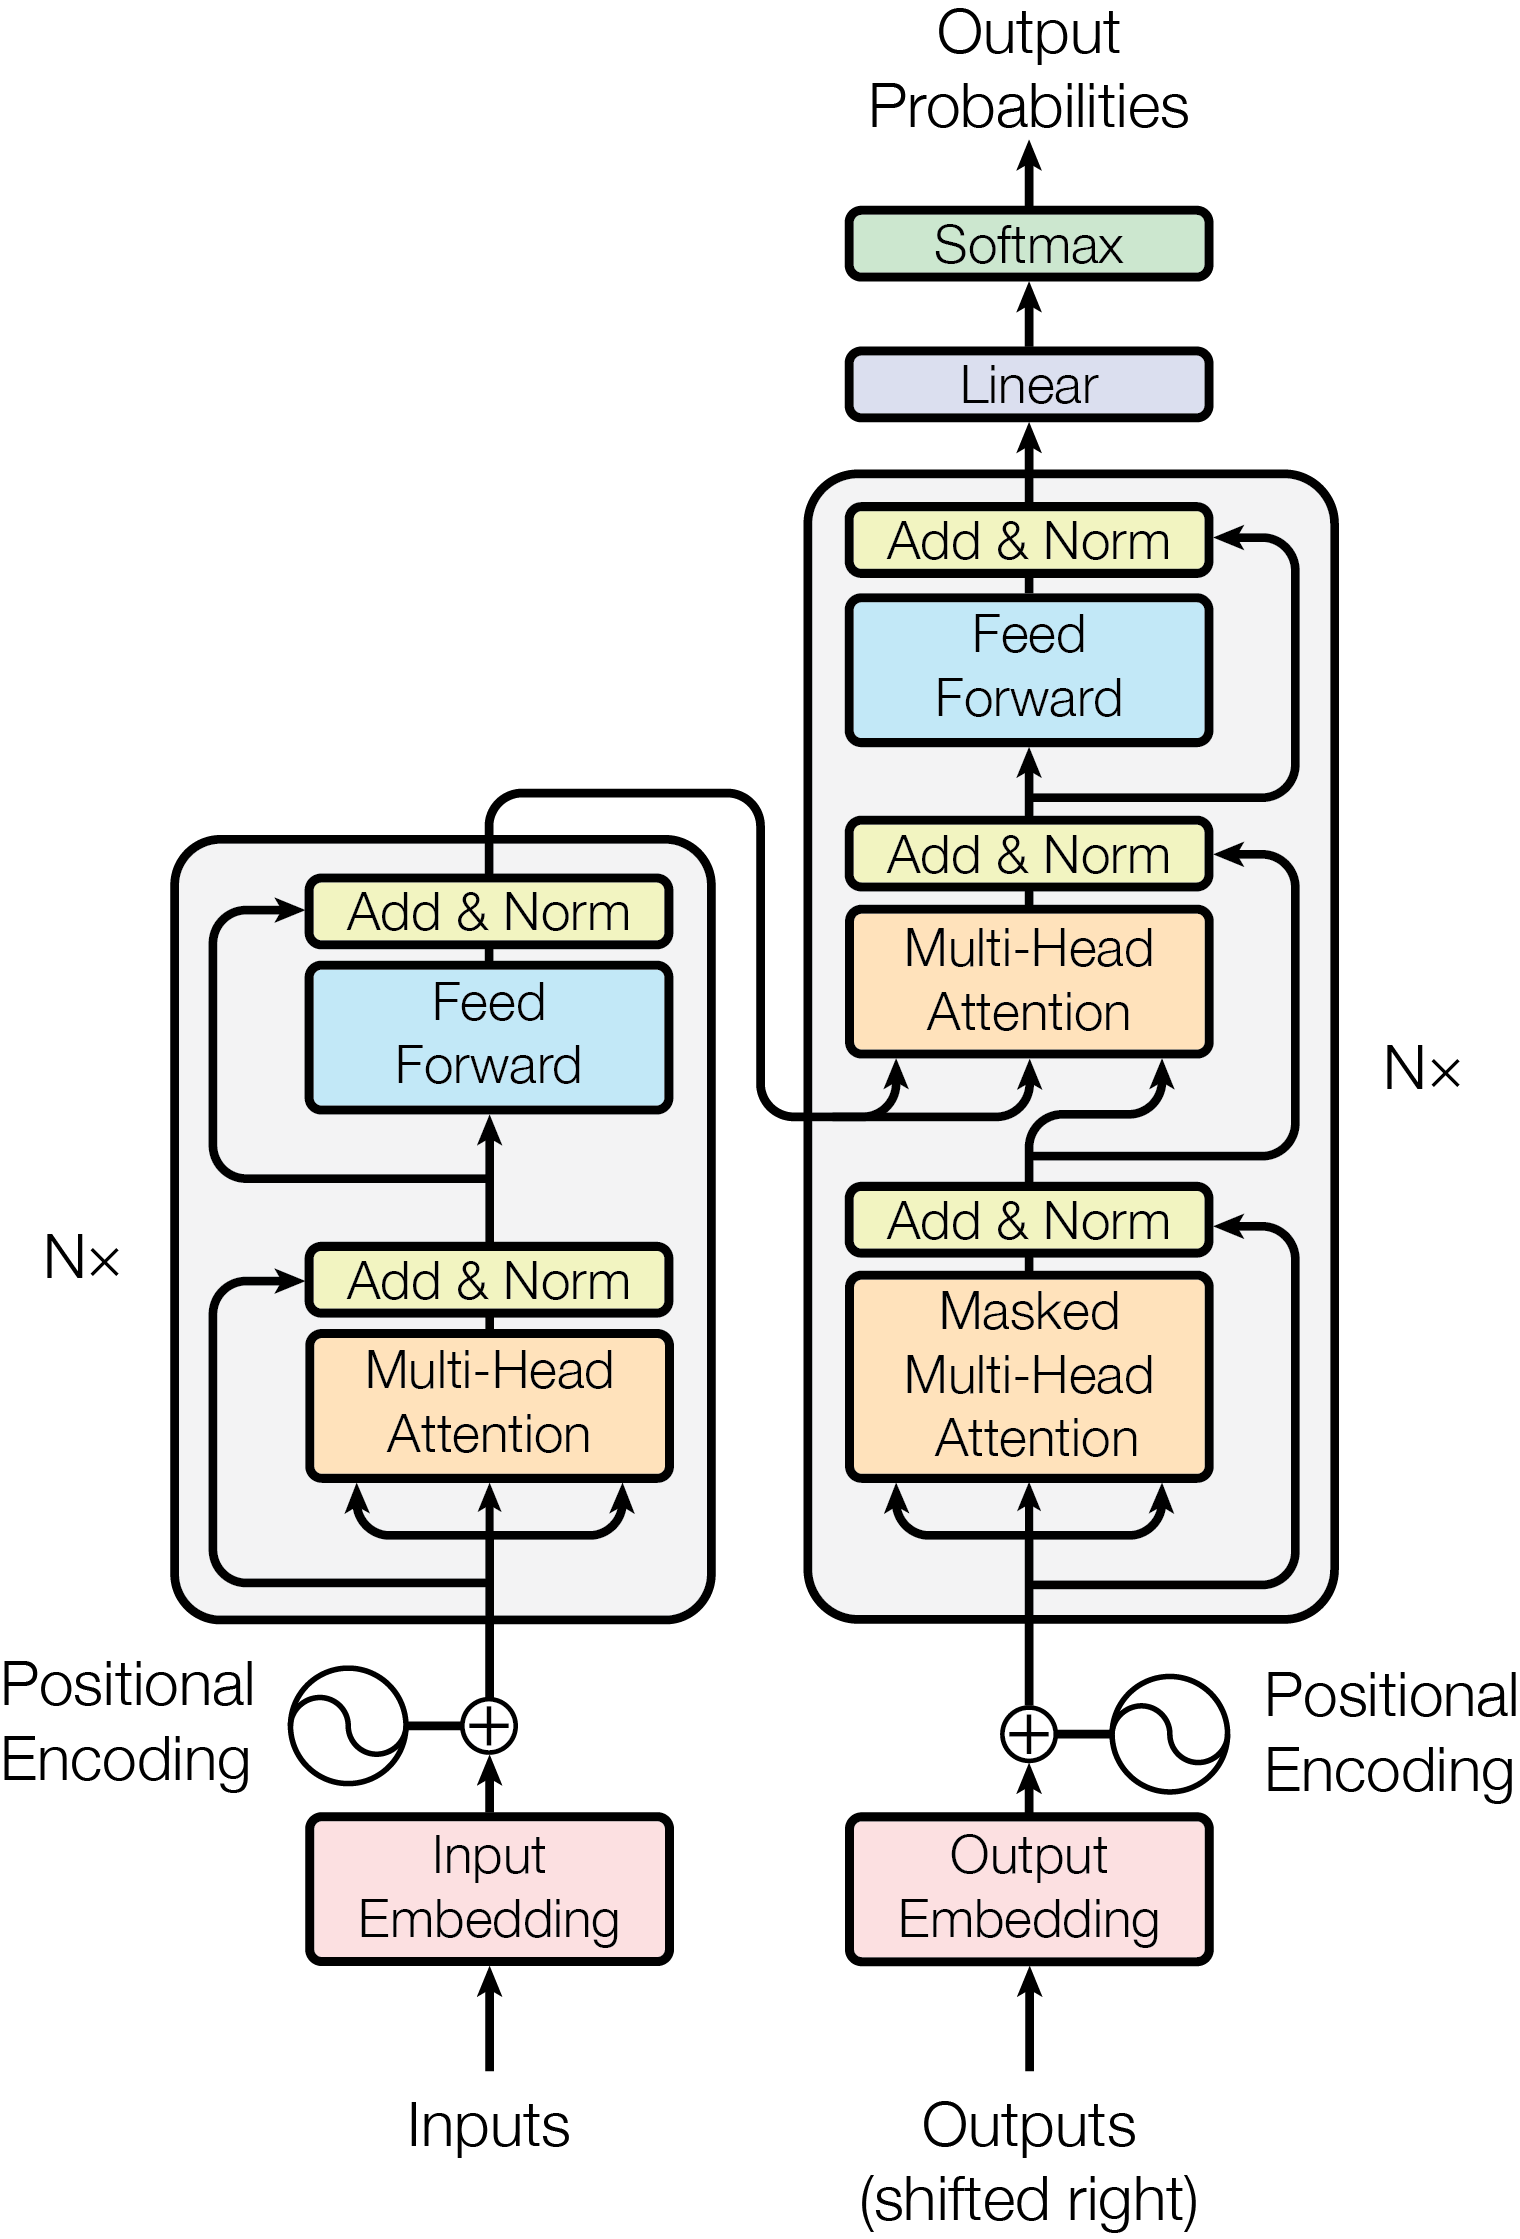

In [ ]:
import requests
from IPython.display import Image, display

url = "https://drive.usercontent.google.com/download?id=1F1Fg--SX3kvCa0QIAysj5xOCesDuBP7a&export=download&authuser=0"
response = requests.get(url)

# Display using bytes content
display(Image(data=response.content, height=700))

## Complete Transformer Shape Reference Guide

All shapes verified end-to-end.

---

### 1. Core Hyperparameters (Symbols Used Everywhere)

| Symbol | Meaning | "Base" Transformer (Vaswani et al.) |
|--------|---------|-------------------------------------|
| `B` | batch size | task-dependent |
| `L` (or `L_enc`, `L_dec`) | sequence length | task-dependent, e.g. 512 |
| `V` | vocabulary size | ~30k–50k (BPE) |
| `d_model` | model/embedding dimension | 512 |
| `h` | number of attention heads | 8 |
| `d_k` | dim per head for Q/K = `d_model / h` | 64 |
| `d_v` | dim per head for V (usually = `d_k`) | 64 |
| `d_ff` | FFN inner dimension | 2048 (= 4×`d_model`) |
| `N` | number of encoder/decoder layers | 6 |

> **Constraint:** `h × d_k = d_model` must always hold (so heads can be concatenated back to `d_model`).

---

### 2. Matrix Dimensions at Every Stage

#### Embedding + Positional Encoding

| Tensor | Shape |
|--------|-------|
| Token embedding table | `(V, d_model)` |
| Input token ids | `(B, L)` |
| Embedded input | `(B, L, d_model)` |
| Positional encoding | `(L, d_model)` — broadcasts over `B` |
| `X = embed + PE` | `(B, L, d_model)` |

#### Multi-Head Attention (Self or Cross)

| Tensor | Shape | Note |
|--------|-------|------|
| `Wq, Wk, Wv` | `(d_model, d_model)` | really `(d_model, h·d_k)`, split later |
| `Q = X·Wq` | `(B, L, d_model)` | for cross-attn, uses decoder `X` |
| `K = X·Wk`, `V = X·Wv` | `(B, L, d_model)` | for cross-attn, uses **encoder** output, so `L = L_enc` here |
| after head-split | `(B, h, L, d_k)` | reshape `(B,L,h,d_k)` → transpose |
| `scores = QKᵀ/√d_k` | `(B, h, L_q, L_k)` | **self-attn**: `L_q = L_k`. **cross-attn**: `L_q = L_dec`, `L_k = L_enc` — the one place the matrix is deliberately non-square |
| `attn = softmax(scores)` | `(B, h, L_q, L_k)` | rows sum to 1 |
| `head_out = attn·V` | `(B, h, L_q, d_v)` | |
| concat heads | `(B, L_q, h·d_v)` = `(B, L_q, d_model)` | transpose back, merge head dim |
| `Wo` | `(h·d_v, d_model)` | output projection |
| MHA output | `(B, L_q, d_model)` | same shape as the query input — enables stacking layers |

#### Feed-Forward Sublayer

| Tensor | Shape |
|--------|-------|
| `W1` | `(d_model, d_ff)` |
| `b1` | `(d_ff,)` |
| hidden = ReLU(`x·W1+b1`) | `(B, L, d_ff)` |
| `W2` | `(d_ff, d_model)` |
| `b2` | `(d_model,)` |
| FFN output | `(B, L, d_model)` |

#### LayerNorm

`γ, β` are both `(d_model,)`, applied per-token over the last axis. Input/output shape unchanged: `(B, L, d_model)`.

##### Output Head

| Tensor | Shape |
|--------|-------|
| `W_out` (often tied to embedding table transposed) | `(d_model, V)` |
| logits | `(B, L_dec, V)` |
| probs = softmax(logits) | `(B, L_dec, V)` |

---

##### The Key Invariant

> **Every sublayer takes `(B, L, d_model)` in and returns `(B, L, d_model)` out.**

This is what lets you stack `N` identical encoder/decoder layers arbitrarily deep — nothing about the shape changes layer to layer, only the content.

---

### 3. Common Calculations / Formulas

- **Attention complexity:** `O(L² · d_model)` — the `scores` matrix is `L×L` per head, the dominant cost. This is *the* reason long-context transformers are expensive and why alternatives (linear attention, sparse attention, sliding window) target this term.

- **Scaling factor:** `1/√d_k` — without it, dot products grow with `d_k` and push softmax into saturated (near one-hot / vanishing-gradient) regions. This connects to why `d_k` and `d_model` can't be picked independently of head count.

- **Parameter count per encoder layer** (roughly):
  - MHA: `Wq + Wk + Wv + Wo` → `4·d_model²`
  - FFN: `W1 + W2` → `2·d_model·d_ff` (= `8·d_model²` when `d_ff = 4·d_model`)
  - LayerNorm: `~4·d_model` (negligible)
  - Total ≈ `12·d_model²` per layer
  - Base model: `12 × 512² ≈ 3.1M` params/layer × 6 layers ≈ **~19M** for the encoder stack alone (decoder roughly doubles this since it has both self-attn and cross-attn)

- **Total model params** ≈ embedding (`V·d_model`, often tied with output projection) + `N·(encoder layer params)` + `N·(decoder layer params, ~1.5× encoder layer)`

- **Causal mask cost:** free in terms of extra params — it's just `L×L` boolean, applied additively as `-inf` before softmax.

---

### 4. Dry Run — Exact Shapes Traced Through One Full Pass

**Toy config:** `B=1, L_enc = L_dec = 4, d_model = 8, h = 2 → d_k = d_v = 4, d_ff = 16, V = 12`

```
Embedding + PE:
  token_ids_enc                   (1, 4)
  X_enc (embeds + PE)             (1, 4, 8)

Encoder self-attention:
  Wq/Wk/Wv                        (8, 8)
  Q = X @ Wq                      (1, 4, 8)
  Q_heads (after split)           (1, 2, 4, 4)     <- (B, h, L, d_k)
  scores = QK^T/sqrt(d_k)         (1, 2, 4, 4)     <- square, L_enc x L_enc
  head_out = attn @ V             (1, 2, 4, 4)
  concat heads                    (1, 4, 8)
  MHA output = concat @ Wo        (1, 4, 8)

Add & Norm + FFN:
  resid1 = X + MHA_out            (1, 4, 8)
  W1 (d_model -> d_ff)            (8, 16)
  ffn_hidden                      (1, 4, 16)
  W2 (d_ff -> d_model)            (16, 8)
  encoder_layer_out (final)       (1, 4, 8)

Decoder masked self-attention:
  X_dec (embeds + PE)             (1, 4, 8)
  dec_self_out                    (1, 4, 8)
  resid_d1                        (1, 4, 8)

Decoder cross-attention:
  Qc (from decoder)               (1, 2, 4, 4)
  Kc (from encoder, len=L_enc)    (1, 2, 4, 4)
  cross scores (L_dec x L_enc)    (1, 2, 4, 4)     <- would be non-square if L_enc != L_dec
  cross_out                       (1, 4, 8)
  decoder_layer_out (final)       (1, 4, 8)

Final projection:
  W_out (d_model -> vocab)        (8, 12)
  logits                          (1, 4, 12)
  probs                           (1, 4, 12)
```



The Transformer architecture, introduced in the seminal paper "Attention Is All You Need" [1], revolutionized sequence modeling by entirely dispensing with recurrence and convolutions. Its core innovation lies in the extensive use of self-attention mechanisms, enabling parallel processing of input sequences and superior capture of long-range dependencies.



## Self-Attention

At the heart of the Transformer architecture is the **Self-Attention mechanism**. Unlike traditional attention where a decoder attends to an encoder, self-attention allows each element in a sequence to attend to all other elements within the *same* sequence. This enables the model to weigh the importance of different words in the input when processing each word, effectively capturing contextual relationships regardless of their distance.

The self-attention mechanism can be thought of as a function that maps a query and a set of key-value pairs to an output. The output is a weighted sum of the values, where the weight assigned to each value is computed by a compatibility function of the query with the corresponding key.

### Query (Q), Key (K), and Value (V)

For each input token (word embedding) in a sequence, three different vectors are created: **Query (Q)**, **Key (K)**, and **Value (V)**. These are derived by multiplying the input embedding (or the output of the previous layer) by three different learned weight matrices ($W^Q$, $W^K$, $W^V$).

*   **Query (Q):** Represents what we are looking for. When computing the attention for a specific word, its Query vector is used to query all other words.
*   **Key (K):** Represents what each word contains. Each word's Key vector is compared against the Query of other words to determine relevance.
*   **Value (V):** Represents the actual content or information of each word. Once relevance is determined, the Value vectors are weighted and summed to form the output.

**Example (Conceptual):**
Consider the sentence "The animal didn't cross the street because it was too tired."
When processing the word "it", the Query vector for "it" will be compared against the Key vectors of all other words in the sentence. If the Key vector for "animal" is highly similar to the Query vector for "it", it suggests that "it" refers to "animal". The Value vector for "animal" would then contribute significantly to the contextual representation of "it".

### Dot Product (Similarity Score)

To determine how much each word should attend to other words, a similarity score is calculated. The most common method is the **dot product** between the Query vector of the current word and the Key vector of every other word in the sequence (including itself).

$Score(Q_i, K_j) = Q_i \cdot K_j$

This dot product measures the similarity or relevance between the query and each key. A higher dot product indicates greater similarity and thus greater relevance.

### Scaling

After computing the dot products, the scores are typically **scaled down** by dividing them by the square root of the dimension of the Key vectors ($\sqrt{d_k}$). This scaling is crucial for stabilizing the training process, especially when $d_k$ is large. Without scaling, the dot products can become very large, pushing the softmax function into regions where its gradients are extremely small, leading to vanishing gradients.

$ScaledScore(Q_i, K_j) = \frac{Q_i \cdot K_j}{\sqrt{d_k}}$

### Softmax

The scaled scores are then passed through a **softmax function**. The softmax function converts these raw scores into a probability distribution, ensuring that all attention weights are positive and sum up to 1. These weights indicate the importance of each word in the input sequence when computing the output for the current word.

$AttentionWeights = Softmax(ScaledScores)$

### Context Vector (Weighted Sum of Values)

Finally, the attention weights are multiplied by their corresponding **Value (V)** vectors. These weighted Value vectors are then summed up to produce the **context vector** for the current word. This context vector is a rich representation that incorporates information from all other words in the sequence, weighted by their relevance to the current word.

$ContextVector_i = \sum_{j=1}^{L} AttentionWeights_{ij} \cdot V_j$

Where $L$ is the length of the sequence.

This entire process is often summarized by the equation:

$Attention(Q, K, V) = Softmax(\frac{QK^T}{\sqrt{d_k}})V$

### Dry Run Example: Self-Attention for a single word

Let's consider a simplified example with a sentence: "I love NLP"

Assume we are calculating the self-attention output for the word "love".

1.  **Input Embeddings:** Each word is converted into an embedding vector.
    *   $E_I$, $E_{love}$, $E_{NLP}$

2.  **Generate Q, K, V Matrices:** For each word, we multiply its embedding by learned weight matrices $W^Q, W^K, W^V$ to get its Q, K, V vectors.
    *   $Q_{love} = E_{love} W^Q$
    *   $K_I = E_I W^K$, $K_{love} = E_{love} W^K$, $K_{NLP} = E_{NLP} W^K$
    *   $V_I = E_I W^V$, $V_{love} = E_{love} W^V$, $V_{NLP} = E_{NLP} W^V$

3.  **Calculate Dot Products (Scores) for $Q_{love}$:** We compare $Q_{love}$ with all Key vectors.
    *   $Score(love, I) = Q_{love} \cdot K_I$
    *   $Score(love, love) = Q_{love} \cdot K_{love}$
    *   $Score(love, NLP) = Q_{love} \cdot K_{NLP}$

4.  **Scale the Scores:** Divide each score by $\sqrt{d_k}$.
    *   $ScaledScore(love, I) = \frac{Q_{love} \cdot K_I}{\sqrt{d_k}}$
    *   $ScaledScore(love, love) = \frac{Q_{love} \cdot K_{love}}{\sqrt{d_k}}$
    *   $ScaledScore(love, NLP) = \frac{Q_{love} \cdot K_{NLP}}{\sqrt{d_k}}$

5.  **Apply Softmax:** Convert scaled scores into attention weights.
    *   $Weight(love, I) = Softmax(ScaledScore(love, I))$
    *   $Weight(love, love) = Softmax(ScaledScore(love, love))$
    *   $Weight(love, NLP) = Softmax(ScaledScore(love, NLP))$
    (These weights sum to 1)

6.  **Compute Context Vector for "love":** Multiply each Value vector by its corresponding attention weight and sum them up.
    *   $ContextVector_{love} = Weight(love, I) \cdot V_I + Weight(love, love) \cdot V_{love} + Weight(love, NLP) \cdot V_{NLP}$

This $ContextVector_{love}$ is the output of the self-attention layer for the word "love", enriched with contextual information from "I" and "NLP" based on their relevance. This process is performed in parallel for every word in the sequence.
### Multi-Head Attention

**Multi-Head Attention** is an extension of the self-attention mechanism that allows the model to jointly attend to information from different representation subspaces at different positions. Instead of performing a single attention function, the input is linearly projected $h$ times with different, learned linear projections to $Q$, $K$, and $V$. Then, attention is performed in parallel for each of these projected versions.

**How it works:**

1.  **Multiple "Heads":** The input $Q, K, V$ are split into $h$ different "heads" or subspaces. For each head, separate linear transformations are applied to the input embeddings to create distinct $Q_i, K_i, V_i$ matrices.
2.  **Parallel Attention:** The scaled dot-product attention function is then applied in parallel to each of these $h$ sets of $(Q_i, K_i, V_i)$. This results in $h$ different attention outputs.
3.  **Concatenation:** The outputs from all $h$ attention heads are concatenated together.
4.  **Linear Projection:** The concatenated output is then linearly projected once more (multiplied by a final weight matrix $W^O$) to produce the final output of the Multi-Head Attention layer. This projection brings the dimension back to the original input dimension.

$MultiHead(Q, K, V) = Concat(head_1, ..., head_h)W^O$
where $head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)$

**Advantages of Multi-Head Attention:**

*   **Enriched Representation:** Allows the model to capture different types of relationships and dependencies. For example, one head might focus on syntactic dependencies, while another focuses on semantic relationships.
*   **Focus on Different Positions:** Each head can learn to attend to different parts of the input sequence, providing a more comprehensive understanding of the context.
*   **Stabilizes Training:** Averaging the results from multiple attention heads can lead to more stable and robust training.

**Example (Conceptual):**
In the sentence "The animal didn't cross the street because it was too tired."

*   One attention head might learn to associate "it" with "animal" (semantic link).
*   Another head might learn to associate "it" with "tired" (grammatical subject-verb agreement).
*   A third head might focus on the negation "didn't" and its scope.

By combining these different perspectives, Multi-Head Attention creates a richer and more nuanced contextual representation for each word.

### Positional Encoding

Since the Transformer architecture completely eschews recurrence and convolutions, it inherently loses information about the relative or absolute position of tokens in the sequence. For tasks like language understanding, word order is crucial (e.g., "dog bites man" vs. "man bites dog"). To reintroduce this vital sequential information, **Positional Encodings** are added to the input embeddings.

**How it works:**

Positional encodings are vectors that carry information about the position of each token in the sequence. These vectors have the same dimension as the input embeddings, allowing them to be simply summed with the word embeddings. The sum of the word embedding and its corresponding positional encoding is then fed into the subsequent layers of the Transformer.

The original Transformer paper uses sine and cosine functions of different frequencies to generate these positional encodings:

$PE_{(pos, 2i)} = sin(pos / 10000^{2i/d_{model}})$
$PE_{(pos, 2i+1)} = cos(pos / 10000^{2i/d_{model}})$

Where:
*   $pos$ is the position of the token in the sequence (e.g., 0 for the first word, 1 for the second, etc.).
*   $i$ is the dimension within the positional encoding vector (from 0 to $d_{model}/2 - 1$).
*   $d_{model}$ is the dimension of the model (i.e., the embedding dimension).

**Why sine and cosine functions?**

*   **Unique Representation:** Each position gets a unique encoding.
*   **Relative Position Information:** The use of sine and cosine functions allows the model to easily learn to attend to relative positions. For any fixed offset $k$, $PE_{pos+k}$ can be represented as a linear function of $PE_{pos}$. This property is beneficial because it means that the model can learn to recognize patterns that are invariant to their absolute position in the sequence.
*   **Generalization to Longer Sequences:** These functions can generate positional encodings for sequences longer than those encountered during training, as they are not learned but rather fixed mathematical functions.

**Example:**
Consider the sentence "I like apples".

1.  **Word Embeddings:** Each word is converted into a $d_{model}$-dimensional embedding vector.
    *   $E_I$, $E_{like}$, $E_{apples}$
2.  **Positional Encodings:** For each position, a $d_{model}$-dimensional positional encoding vector is generated.
    *   $PE_0$ for "I" (position 0)
    *   $PE_1$ for "like" (position 1)
    *   $PE_2$ for "apples" (position 2)
3.  **Combined Input:** The final input to the Transformer layers for each word is the sum of its word embedding and its positional encoding.
    *   Input for "I" = $E_I + PE_0$
    *   Input for "like" = $E_{like} + PE_1$
    *   Input for "apples" = $E_{apples} + PE_2$

This combined vector now contains both the semantic information of the word and its position within the sentence, allowing the self-attention mechanism to leverage this order information.

### Feed Forward Network

After the Multi-Head Attention layer, each position in the Transformer's encoder and decoder blocks passes through a simple, position-wise **Feed-Forward Network (FFN)**. This FFN is applied independently and identically to each position. It consists of two linear transformations with a ReLU activation in between.

$FFN(x) = max(0, xW_1 + b_1)W_2 + b_2$

Where:
*   $x$ is the output from the Multi-Head Attention layer for a specific position.
*   $W_1, b_1, W_2, b_2$ are learned parameters. Importantly, these parameters are the same for every position, but they are different for each layer of the Transformer.

**Purpose of the Feed-Forward Network:**

*   **Non-linearity:** The FFN introduces non-linearity into the model, allowing it to learn more complex patterns than a purely linear model. The ReLU activation function is key here.
*   **Feature Transformation:** It transforms the representation of each position independently. While self-attention allows information to flow between different positions, the FFN processes each position's representation in isolation, allowing it to learn complex, position-specific feature transformations.
*   **Increased Model Capacity:** The FFN contributes significantly to the model's capacity to learn and represent intricate relationships within the data.

**Example:**
Imagine the output from the Multi-Head Attention layer for the word "bank" (which has been contextualized by other words in the sentence). This contextualized vector for "bank" is then fed into the FFN. The FFN might learn to emphasize certain features within this vector that are relevant for disambiguating its meaning (e.g., whether it refers to a financial institution or a river bank), or for preparing it for subsequent layers.

### Residual Connection (Skip Connection)

Both the Multi-Head Attention sub-layer and the Feed-Forward Network sub-layer in the Transformer architecture are followed by a **Residual Connection**, also known as a **Skip Connection**. This concept, popularized by ResNet architectures in computer vision, involves adding the input of a sub-layer directly to its output.

Mathematically, if $X$ is the input to a sub-layer and $Sublayer(X)$ is the function computed by the sub-layer, the output with a residual connection is:

$Output = X + Sublayer(X)$

**Purpose of Residual Connections:**

*   **Mitigate Vanishing Gradients:** In deep neural networks, gradients can vanish as they propagate backward through many layers. Residual connections provide a direct path for gradients to flow, allowing them to bypass non-linear transformations and reach earlier layers more effectively. This helps in training very deep networks.
*   **Facilitate Identity Mapping:** They allow the network to easily learn an identity function. If a sub-layer doesn't need to transform its input, it can simply learn to output zero, and the residual connection ensures the input is passed through unchanged. This makes it easier for the network to learn incremental changes rather than entirely new transformations.
*   **Improved Training Stability:** By providing alternative paths for information flow, residual connections contribute to more stable training and faster convergence of deep models.

**Example:**
Consider a deep Transformer model with many layers. Without residual connections, if a particular attention or FFN sub-layer is not learning effectively, the information might degrade significantly as it passes through. With a residual connection, the original input signal is preserved and added to the sub-layer's output, ensuring that at least the original information is available to the next layer, even if the sub-layer's transformation is not perfect.

### Layer Normalization

Following each sub-layer (Multi-Head Attention and Feed-Forward Network) in the Transformer, and *after* the residual connection, **Layer Normalization** is applied. This technique normalizes the inputs across the features for each sample independently, rather than across a batch of samples (as in Batch Normalization).

Mathematically, for an input $x$ to a layer, Layer Normalization computes the mean ($\mu$) and variance ($\sigma^2$) of the features for each individual sample:

$\mu = \frac{1}{D} \sum_{i=1}^{D} x_i$
$\sigma^2 = \frac{1}{D} \sum_{i=1}^{D} (x_i - \mu)^2$

Then, the normalized output $y$ is calculated as:

$y = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \cdot \gamma + \beta$

Where:
*   $D$ is the number of features (e.g., $d_{model}$).
*   $\epsilon$ is a small constant to prevent division by zero.
*   $\gamma$ and $\beta$ are learned scaling and shifting parameters, respectively, allowing the network to restore the original representation if needed.

**Purpose of Layer Normalization:**

*   **Stabilizes Training:** Normalizing the activations helps to stabilize the training process, especially in deep networks, by keeping the input distribution to subsequent layers consistent. This prevents issues like exploding or vanishing activations.
*   **Faster Convergence:** By reducing internal covariate shift (the change in the distribution of network activations due to the change in network parameters during training), Layer Normalization allows for higher learning rates and faster convergence.
*   **Independent of Batch Size:** Unlike Batch Normalization, Layer Normalization computes statistics independently for each training example. This makes it particularly well-suited for RNNs and Transformers, where batch sizes can vary or be small, and for tasks where sequence lengths differ within a batch.

**Example:**
Consider a vector representing a word after it has passed through a Multi-Head Attention layer and had its residual connection added. This vector has $d_{model}$ dimensions. Layer Normalization will calculate the mean and variance across these $d_{model}$ dimensions for *that single word vector*. It then normalizes these values and applies learned scaling and shifting, ensuring that the features for that word are in a stable range before being passed to the next sub-layer or block. This process is applied independently to every word vector in the sequence.

### Encoder Block

The Transformer architecture is composed of a stack of identical **Encoder Blocks**. Each encoder block is responsible for processing a portion of the input sequence and transforming it into a richer, contextualized representation. The original Transformer model uses 6 such encoder blocks stacked on top of each other.

Each Encoder Block consists of two main sub-layers:

1.  **Multi-Head Self-Attention Mechanism:** This sub-layer allows the encoder to weigh the importance of different words in the input sequence when processing each word. It computes a contextualized representation for each input token by attending to all other tokens in the sequence. As described previously, this involves the Query, Key, and Value transformations, dot-product attention, scaling, softmax, and concatenation of multiple attention heads.

2.  **Position-wise Feed-Forward Network (FFN):** This sub-layer is applied independently to each position in the sequence. It consists of two linear transformations with a ReLU activation in between, providing non-linearity and allowing the model to learn complex, position-specific feature transformations.

Crucially, each of these two sub-layers is followed by a **Residual Connection** and then **Layer Normalization**.

$Output_{EncoderBlock} = LayerNorm(Input + Sublayer(Input))$

**Flow within an Encoder Block:**

1.  **Input:** The input to the first encoder block is the sum of the word embeddings and their corresponding positional encodings. For subsequent encoder blocks, the input is the output of the previous encoder block.
2.  **Multi-Head Self-Attention:** The input passes through the Multi-Head Self-Attention layer. This layer computes a new representation for each token, incorporating information from all other tokens in the sequence.
3.  **Add & Norm 1:** The output of the Multi-Head Self-Attention layer is added to its input (residual connection), and then Layer Normalization is applied.
4.  **Feed-Forward Network:** The normalized output then passes through the Position-wise Feed-Forward Network.
5.  **Add & Norm 2:** The output of the FFN is added to its input (residual connection), and then Layer Normalization is applied.
6.  **Output:** The final output of the encoder block is a sequence of contextualized representations, one for each input token. This output then becomes the input for the next encoder block in the stack, or the input to the decoder.

**Example (Conceptual):**
Imagine an encoder block processing the sentence "The cat sat on the mat." For the word "cat", the Multi-Head Self-Attention layer will consider "The", "sat", "on", "the", "mat" to form a richer representation of "cat" that understands its role as the subject. This contextualized "cat" representation then goes through the FFN to further refine its features. This process happens for all words, and the output is a new sequence of vectors, where each vector is a highly contextualized representation of its corresponding input word.

### Decoder Block

The Transformer architecture also consists of a stack of identical **Decoder Blocks**, typically 6 of them, similar to the encoder. The decoder's role is to generate the output sequence one token at a time, taking the encoder's output (the contextualized representations of the input sequence) and the previously generated output tokens as input.

Each Decoder Block is more complex than an Encoder Block, consisting of three main sub-layers:

1.  **Masked Multi-Head Self-Attention:** This sub-layer is similar to the encoder's self-attention but with a crucial modification: it is **masked**. This masking ensures that when predicting the next token, the decoder can only attend to previously generated tokens and the current token, not future tokens. This prevents information leakage from future tokens during training, maintaining the auto-regressive property of sequence generation.

2.  **Multi-Head Cross-Attention (Encoder-Decoder Attention):** This sub-layer allows the decoder to attend to the output of the encoder stack. Here, the Query (Q) comes from the *decoder's* previous layer, while the Key (K) and Value (V) come from the *encoder's* output. This mechanism enables the decoder to focus on relevant parts of the input sequence when generating each output token, similar to how attention worked in the original Seq2Seq models.

3.  **Position-wise Feed-Forward Network (FFN):** Similar to the encoder, this sub-layer is applied independently to each position, providing non-linearity and feature transformation.

Again, each of these three sub-layers is followed by a **Residual Connection** and then **Layer Normalization**.

**Flow within a Decoder Block:**

1.  **Input:** The input to the first decoder block is the sum of the previously generated output token embeddings and their corresponding positional encodings. For subsequent decoder blocks, the input is the output of the previous decoder block.
2.  **Masked Multi-Head Self-Attention:** The input passes through this layer. Each token attends to all preceding tokens in the *decoder's own output sequence*.
3.  **Add & Norm 1:** Residual connection and Layer Normalization are applied.
4.  **Multi-Head Cross-Attention:** The output from the previous step (decoder's contextualized representation) acts as the Query. The Key and Value come from the final output of the encoder stack. This allows the decoder to attend to the source input.
5.  **Add & Norm 2:** Residual connection and Layer Normalization are applied.
6.  **Feed-Forward Network:** The output then passes through the Position-wise Feed-Forward Network.
7.  **Add & Norm 3:** Residual connection and Layer Normalization are applied.
8.  **Output:** The final output of the decoder block is a sequence of contextualized representations, which are then typically passed to a final linear layer and softmax function to predict the probability distribution over the vocabulary for the next token.

**Example (Conceptual):**
Imagine the decoder generating a translation for "The cat sat on the mat." When it's about to generate "chat" (cat in French):

*   The **Masked Self-Attention** would ensure it only looks at "Le" (The) and the start-of-sequence token, but not at "était" (was) or "assis" (sat) yet.
*   The **Cross-Attention** would then take the decoder's current state (contextualized by "Le") and query the encoder's output. It would likely assign high attention weights to the encoder's representation of "The" and "cat" from the English input, helping it decide to generate "chat".

This iterative process, guided by both its own generated history and the full source input, allows the decoder to generate coherent and contextually relevant output sequences.

### Complete Forward Pass

The **Complete Forward Pass** of a Transformer model involves the sequential execution of its Encoder and Decoder components to transform an input sequence into an output sequence. This process is fundamental to how Transformers perform tasks like machine translation, text summarization, and question answering.

#### Encoder Forward Pass:

1.  **Input Preparation:** The input sequence (e.g., source sentence) is first converted into **word embeddings**. These embeddings are then combined with **positional encodings** to inject information about the word order. This combined representation forms the initial input to the encoder stack.

2.  **Encoder Stack Processing:** The prepared input sequence passes through a stack of $N$ identical **Encoder Blocks** (typically $N=6$).
    *   Each Encoder Block processes the sequence through its **Multi-Head Self-Attention** layer, followed by a **Feed-Forward Network (FFN)**.
    *   Crucially, each sub-layer (Self-Attention and FFN) is wrapped with a **Residual Connection** and **Layer Normalization**.
    *   The Multi-Head Self-Attention allows each word to attend to all other words in the input sequence, creating a rich contextual representation.
    *   The FFN further processes these contextualized representations independently for each position.

3.  **Encoder Output:** The final output of the encoder stack is a sequence of contextualized representations (often called memory keys and values) for each word in the input sequence. This output is then passed to the decoder.

#### Decoder Forward Pass:

1.  **Input Preparation:** The decoder receives two main inputs:
    *   The **encoder's output** (memory keys and values).
    *   The **previously generated output sequence** (e.g., target sentence generated so far), which is also converted into word embeddings and combined with positional encodings. During training, this is the actual target sequence shifted right (so the model predicts the next token). During inference, it starts with a special `[START]` token and iteratively appends its own predictions.

2.  **Decoder Stack Processing:** The prepared decoder input passes through a stack of $N$ identical **Decoder Blocks** (typically $N=6$).
    *   Each Decoder Block contains three sub-layers:
        *   **Masked Multi-Head Self-Attention:** This layer allows the decoder to attend to previously generated tokens in its *own output sequence*. The masking ensures that attention is only paid to past tokens, preserving the auto-regressive property.
        *   **Multi-Head Cross-Attention (Encoder-Decoder Attention):** This layer takes Queries from the decoder's masked self-attention output and Keys/Values from the encoder's final output. This allows the decoder to focus on relevant parts of the *input sequence* when generating the next output token.
        *   **Feed-Forward Network (FFN):** Similar to the encoder, this FFN processes the contextualized representations independently for each position.
    *   Again, each sub-layer is followed by a **Residual Connection** and **Layer Normalization**.

3.  **Output Layer:** The final output of the decoder stack is passed through a linear layer, followed by a softmax function. This produces a probability distribution over the entire vocabulary for the next token in the output sequence.

4.  **Token Prediction:** During training, the predicted probabilities are compared to the actual next token to calculate the loss. During inference, the token with the highest probability is selected as the next word, and this word is then fed back into the decoder as part of the input for the next time step, until an `[END]` token is generated or a maximum length is reached.

#### Dry Run Example: Translating "Hello world" to French "Bonjour le monde"

**Assumptions:**
*   Input sequence: `[START] Hello world [END]`
*   Target sequence (for training): `[START] Bonjour le monde [END]`
*   Vocabulary includes `Hello`, `world`, `Bonjour`, `le`, `monde`, `[START]`, `[END]`
*   $N=1$ Encoder Block, $N=1$ Decoder Block for simplicity.

**Encoder Forward Pass:**

1.  **Input:** `[START] Hello world [END]` is converted to embeddings + positional encodings.
    *   `E_start + PE_0`, `E_hello + PE_1`, `E_world + PE_2`, `E_end + PE_3`
2.  **Encoder Block:** These combined vectors pass through the Encoder Block.
    *   **Multi-Head Self-Attention:** Each token attends to all other tokens. `E_hello` now contains information about `world` and `[START]`, etc.
    *   **FFN:** Further transforms these contextualized representations.
    *   **Output:** `C_start`, `C_hello`, `C_world`, `C_end` (contextualized representations of the input sequence).

**Decoder Forward Pass (Inference - generating output one token at a time):**

*   **Step 1: Predict "Bonjour"**
    1.  **Decoder Input:** `[START]` token embedding + positional encoding (`E_start_dec + PE_0`).
    2.  **Decoder Block:**
        *   **Masked Self-Attention:** `E_start_dec + PE_0` attends only to itself (as it's the only token so far).
        *   **Cross-Attention:** Queries from the masked self-attention output attend to `C_start`, `C_hello`, `C_world`, `C_end` from the encoder. It learns to focus on `C_hello` and `C_world` to predict the first word.
        *   **FFN:** Processes the output.
    3.  **Output Layer:** Linear layer + Softmax predicts `Bonjour` with highest probability.

*   **Step 2: Predict "le"**
    1.  **Decoder Input:** `[START] Bonjour` token embeddings + positional encodings (`E_start_dec + PE_0`, `E_bonjour + PE_1`).
    2.  **Decoder Block:**
        *   **Masked Self-Attention:** `E_bonjour + PE_1` attends to `E_start_dec + PE_0` and itself.
        *   **Cross-Attention:** Queries from the masked self-attention output attend to `C_start`, `C_hello`, `C_world`, `C_end`. It learns to focus on `C_hello` and `C_world` again, but now in the context of `Bonjour` already being generated.
        *   **FFN:** Processes the output.
    3.  **Output Layer:** Linear layer + Softmax predicts `le` with highest probability.

*   **Step 3: Predict "monde"**
    1.  **Decoder Input:** `[START] Bonjour le` token embeddings + positional encodings (`E_start_dec + PE_0`, `E_bonjour + PE_1`, `E_le + PE_2`).
    2.  **Decoder Block:**
        *   **Masked Self-Attention:** `E_le + PE_2` attends to `E_start_dec + PE_0`, `E_bonjour + PE_1` and itself.
        *   **Cross-Attention:** Queries attend to encoder outputs. Focus shifts to `C_world` to predict `monde`.
        *   **FFN:** Processes the output.
    3.  **Output Layer:** Linear layer + Softmax predicts `monde` with highest probability.

*   **Step 4: Predict "[END]"**
    1.  **Decoder Input:** `[START] Bonjour le monde` token embeddings + positional encodings.
    2.  **Decoder Block:** Similar process.
    3.  **Output Layer:** Linear layer + Softmax predicts `[END]` with highest probability.

**Final Output:** `Bonjour le monde`

This iterative process, where the decoder generates one token at a time and feeds its own output back as input, is how the Transformer generates sequences. The parallel nature of self-attention within each block, however, allows for much faster computation compared to traditional RNNs during both training and inference (when generating multiple tokens in parallel within a batch).

## Interview Questions and Answers

This section provides a set of interview questions, ranging from foundational concepts of the Transformer to more advanced topics, along with potential answers and tricky follow-up questions to pinpoint understanding.

### Self-Attention Core

**Q1: What is the fundamental idea behind Self-Attention, and how does it differ from traditional attention mechanisms in RNN-based Seq2Seq models?**

**A1:** Self-Attention allows each element in a sequence to attend to all other elements within the *same* sequence, computing a contextualized representation for each. This differs from traditional attention, where a decoder attends to an encoder (cross-attention), focusing on relevant parts of a *different* sequence. Self-attention enables direct capture of long-range dependencies within a single sequence, regardless of token distance.

**Tricky Follow-up:** If self-attention allows every word to attend to every other word, what is the computational complexity for a sequence of length L, and what are the practical implications for very long sequences?

**Q2: Explain the roles of Query (Q), Key (K), and Value (V) in the Self-Attention mechanism.**

**A2:**
*   **Query (Q):** Represents what we are looking for. For a given word, its Q vector is used to query all other words.
*   **Key (K):** Represents what each word contains. Each word's K vector is compared against the Q of other words to determine relevance.
*   **Value (V):** Represents the actual content or information of each word. Once relevance is determined, the V vectors are weighted and summed to form the output.

**Tricky Follow-up:** Why are Q, K, and V derived from the same input embedding but using different weight matrices? What would happen if they all used the same weight matrix?

**Q3: Why is scaling by $\sqrt{d_k}$ important in the scaled dot-product attention?**

**A3:** Scaling the dot products by $\sqrt{d_k}$ (the square root of the dimension of the Key vectors) is crucial for stabilizing the training process. Without scaling, the dot products can become very large, especially with large $d_k$. This can push the softmax function into regions where its gradients are extremely small, leading to vanishing gradients and hindering effective learning.

**Tricky Follow-up:** What would be the consequence if you omitted the scaling factor, and how might this manifest during model training?

### Structural Components

**Q4: What is Multi-Head Attention, and what advantages does it offer over single-head attention?**

**A4:** Multi-Head Attention is an extension where the input Q, K, V are linearly projected multiple times ($h$ heads) into different representation subspaces. Attention is then performed in parallel for each head, and their outputs are concatenated and linearly projected. Advantages include: (1) **Enriched Representation:** Captures different types of relationships (e.g., syntactic vs. semantic). (2) **Focus on Different Positions:** Each head can learn to attend to different parts of the input. (3) **Stabilizes Training:** Averaging across heads leads to more robust learning.

**Tricky Follow-up:** How does the total number of parameters in Multi-Head Attention compare to a single-head attention mechanism with the same output dimension? Is it more or less efficient in terms of parameter count?

**Q5: Why are Positional Encodings necessary in the Transformer architecture, and how are they typically generated?**

**A5:** Positional Encodings are necessary because the Transformer lacks recurrence or convolutions, meaning it inherently loses information about the order of tokens in a sequence. Word order is crucial for language understanding. They are typically generated using fixed sine and cosine functions of different frequencies, which are then added to the input word embeddings. This provides unique positional information for each token and allows the model to generalize to longer sequences.

**Tricky Follow-up:** If you were to replace sinusoidal positional encodings with learned positional embeddings, what are the potential benefits and drawbacks, especially concerning generalization to unseen sequence lengths?

**Q6: Describe the purpose of the Feed-Forward Network (FFN) within a Transformer block.**

**A6:** The FFN is a simple, position-wise network applied independently to each position after the attention sub-layer. It consists of two linear transformations with a ReLU activation in between. Its purpose is to introduce **non-linearity** into the model, allowing it to learn more complex patterns, and to perform **feature transformation** on the contextualized representation of each token in isolation.

**Tricky Follow-up:** Why is the FFN applied position-wise and independently to each token, rather than across the entire sequence like attention? What does this imply about the FFN's role compared to attention?

### Training & Stability

**Q7: What is a Residual Connection, and why is it important for training deep Transformer models?**

**A7:** A Residual Connection (or skip connection) adds the input of a sub-layer directly to its output ($Output = Input + Sublayer(Input)$). It is crucial for training deep Transformer models because it: (1) **Mitigates Vanishing Gradients:** Provides a direct path for gradients to flow, preventing them from diminishing in deep networks. (2) **Facilitates Identity Mapping:** Allows sub-layers to easily learn an identity function, making it easier for the network to learn incremental changes. (3) **Improves Training Stability** and faster convergence.

**Tricky Follow-up:** How does the concept of residual connections relate to the idea of
Tricky Follow-up: How does the concept of residual connections relate to the idea of enabling deeper networks, and what problem does it specifically solve that makes deeper networks feasible?

**Q8: Explain the role of Layer Normalization in the Transformer architecture, and how it differs from Batch Normalization.**

**A8:** Layer Normalization normalizes the inputs across the features for each individual sample independently. It computes the mean and variance of the features for each token vector and then normalizes them, applying learned scaling and shifting parameters. Its role is to **stabilize training** by keeping the input distribution to subsequent layers consistent, preventing exploding/vanishing activations, and leading to **faster convergence**. It differs from Batch Normalization, which normalizes across the batch dimension for each feature, making Layer Normalization more suitable for variable-length sequences and smaller batch sizes common in NLP.

**Tricky Follow-up:** In what specific scenarios would Layer Normalization be preferred over Batch Normalization in a sequence model, and why is this distinction particularly important for Transformers?

### Architecture: Encoder and Decoder Blocks

**Q9: Describe the main components of an Encoder Block in the Transformer.**

**A9:** An Encoder Block consists of two main sub-layers: a **Multi-Head Self-Attention mechanism** and a **Position-wise Feed-Forward Network (FFN)**. Each of these sub-layers is followed by a **Residual Connection** and **Layer Normalization**. The Multi-Head Self-Attention allows the encoder to create contextualized representations by attending to all words in the input sequence, while the FFN applies non-linear transformations independently to each position.

**Tricky Follow-up:** If you were to remove the FFN from the Encoder Block, what capabilities would the Transformer lose, and how would this impact its ability to learn complex patterns?

**Q10: What are the three main sub-layers in a Decoder Block, and what is the purpose of Masked Multi-Head Self-Attention?**

**A10:** A Decoder Block has three main sub-layers: **Masked Multi-Head Self-Attention**, **Multi-Head Cross-Attention (Encoder-Decoder Attention)**, and a **Position-wise Feed-Forward Network (FFN)**. Each is followed by a Residual Connection and Layer Normalization. The **Masked Multi-Head Self-Attention** is crucial because it ensures that when the decoder is predicting the next token, it can only attend to previously generated tokens and the current token, but *not* to future tokens in the output sequence. This maintains the auto-regressive property required for sequence generation.

**Tricky Follow-up:** Why is the cross-attention layer in the decoder *not* masked, unlike the self-attention layer? What would be the consequence if it were masked?




## Architecture
```text
Transformer Block
        │
        ▼
Multi-Head Attention
        │
        ├── Head 1
        │      ├── Q
        │      ├── K
        │      ├── V
        │      └── Attention(Q,K,V)
        │
        ├── Head 2
        │      ├── Q
        │      ├── K
        │      ├── V
        │      └── Attention(Q,K,V)
        │
        ├── ...
        │
        └── Head h
               ├── Q
               ├── K
               ├── V
               └── Attention(Q,K,V)
        │
        ▼
Concatenate Heads
        │
        ▼
Output Projection
        │
        ▼
Feed Forward Network
```


### Q1. What is an attention head?

**Answer:**  
An attention head is one independent attention mechanism with its own learnable projection matrices (WQ, WK, WV). Each head computes its own attention distribution and context vectors, allowing the model to learn different types of relationships in parallel.

---

### Q2. Why do we need multiple heads instead of one large head?

**Answer:**  
Multiple heads let the model learn different kinds of patterns simultaneously. For example, one head may focus on syntactic relationships, another on semantic similarity, and another on long-range dependencies. Their outputs are concatenated and projected back into the model dimension.

---

### Q3. What is the difference between attention scores and attention weights?

**Answer:**  
- **Attention scores** are the raw similarities computed as **QKᵀ / √dₖ**.  
- **Attention weights** are the probabilities obtained by applying **Softmax** to those scores. These weights determine how much each Value vector contributes to the output.

---

### Q4. What is the difference between a head and Multi-Head Attention?

**Answer:**  
A **head** is a single attention computation with its own Q/K/V projections. **Multi-Head Attention** is a collection of multiple heads running in parallel, whose outputs are concatenated and passed through an output projection.

---

### Q5. What is the difference between self-attention and cross-attention?

**Answer:**  
- In **self-attention**, Q, K, and V are all computed from the same input sequence.  
- In **cross-attention**, Q comes from one sequence (typically the decoder), while K and V come from another sequence (typically the encoder output).

### What is linear layer?
### Describe all the key part in the